In [2]:
!pip uninstall -y transformers datasets torchvision torchaudio

Found existing installation: transformers 5.13.1
Uninstalling transformers-5.13.1:
  Successfully uninstalled transformers-5.13.1
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [3]:
!pip install -q \
transformers==4.53.3 \
datasets==3.6.0 \
accelerate \
evaluate \
sentencepiece \
scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 119.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.28 requires torchvision, which is not installed.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [1]:
import transformers
import datasets

print(transformers.__version__)
print(datasets.__version__)

4.53.3
3.6.0


#**Cell 1 Mount Drive, Load Dataset, Split Dataset**

In [2]:
from google.colab import drive

drive.mount('/content/drive')


# Install required libraries
!pip -q install transformers datasets accelerate scikit-learn sentencepiece


import pandas as pd
import torch

from datasets import Dataset


print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# Load dataset
df = pd.read_csv(
    "/content/drive/MyDrive/dataset/phishing_email_subset_20000.csv"
)

print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(df["label"].value_counts())


# Convert to Hugging Face Dataset
dataset = Dataset.from_pandas(df)


# Split dataset (70% Train, 10% Validation, 20% Test)
train_test = dataset.train_test_split(
    test_size=0.30,
    seed=42
)

validation_test = train_test["test"].train_test_split(
    test_size=2/3,
    seed=42
)

dataset = {
    "train": train_test["train"],
    "validation": validation_test["train"],
    "test": validation_test["test"]
}

print("\nSplit Sizes:")
print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))
print("Test:", len(dataset["test"]))

Mounted at /content/drive
PyTorch: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4
Dataset Shape: (20000, 2)

Class Distribution:
label
0    10000
1    10000
Name: count, dtype: int64

Split Sizes:
Train: 14000
Validation: 2000
Test: 4000


#**Cell 2: Tokenization and DistilBERT Model Initialization**

In [3]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)

# DistilBERT model
model_name = "distilbert-base-uncased"

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)


# Tokenization
def tokenize(batch):

    return tokenizer(
        batch["text_combined"],
        truncation=True,
        max_length=256
    )


# Tokenize dataset
tokenized_dataset = {
    split: data.map(
        tokenize,
        batched=True
    )
    for split, data in dataset.items()
}


# Remove original text column
for split in tokenized_dataset:

    tokenized_dataset[split] = tokenized_dataset[split].remove_columns(
        ["text_combined"]
    )


# Dynamic padding
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)


# Load DistilBERT
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


print(tokenized_dataset["train"].features)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'label': Value(dtype='int64', id=None), 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}


#**Cell 3: Model Training and Evaluation**

In [4]:
from transformers import (
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

import torch


# Evaluation metrics

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = logits.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


# Training configuration

training_args = TrainingArguments(

    output_dir="./distilbert_results",

    num_train_epochs=3,

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    fp16=torch.cuda.is_available(),

    logging_steps=100,

    report_to="none"
)


# Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=tokenized_dataset["train"],

    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)


# Train the model

trainer.train()


# Evaluate on the test set

test_results = trainer.evaluate(
    tokenized_dataset["test"]
)

print("\nTest Results:")
print(test_results)


# Save the trained model

save_path = "/content/drive/MyDrive/dataset/distilbert_phishing_model"

trainer.save_model(save_path)

tokenizer.save_pretrained(save_path)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.080400,0.066418,0.979500,0.978282,0.981188,0.979733
2,0.029000,0.063725,0.984500,0.984174,0.985149,0.984661
3,0.000900,0.077890,0.986500,0.985192,0.988119,0.986653



Test Results:
{'eval_loss': 0.06080954894423485, 'eval_accuracy': 0.98675, 'eval_precision': 0.9873160832064941, 'eval_recall': 0.9858156028368794, 'eval_f1': 0.9865652724968315, 'eval_runtime': 8.0548, 'eval_samples_per_second': 496.601, 'eval_steps_per_second': 31.038, 'epoch': 3.0}


('/content/drive/MyDrive/dataset/distilbert_phishing_model/tokenizer_config.json',
 '/content/drive/MyDrive/dataset/distilbert_phishing_model/special_tokens_map.json',
 '/content/drive/MyDrive/dataset/distilbert_phishing_model/vocab.txt',
 '/content/drive/MyDrive/dataset/distilbert_phishing_model/added_tokens.json',
 '/content/drive/MyDrive/dataset/distilbert_phishing_model/tokenizer.json')

#**Cell 4: Classification Report and Confusion Matrix**

Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      2026
    Phishing       0.99      0.99      0.99      1974

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000


Confusion Matrix:
[[2001   25]
 [  28 1946]]


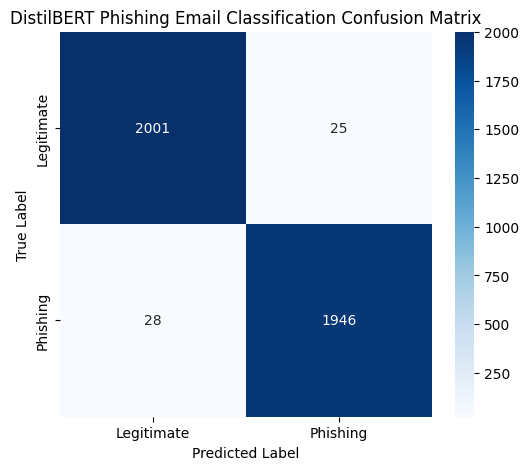

In [5]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


# Predict on the test set

predictions = trainer.predict(
    tokenized_dataset["test"]
)


# Predicted and true labels

y_pred = predictions.predictions.argmax(axis=1)

y_true = predictions.label_ids


# Classification Report

print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ]
    )
)


# Confusion Matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# Plot Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Legitimate",
        "Phishing"
    ],
    yticklabels=[
        "Legitimate",
        "Phishing"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DistilBERT Phishing Email Classification Confusion Matrix")

plt.show()